# Predicting Heart Disease

In [5]:
!pip install eli5

In [6]:
#Import the neccessary libraries for the task
import numpy as np   
import pandas as pd   
import matplotlib.pyplot as plt   
import seaborn as sns
sns.set_style("white")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from eli5.sklearn import PermutationImportance
from sklearn.metrics import confusion_matrix

In [100]:
#install library for feature importance (later to be used in the project)
#!pip install eli5

In [7]:
#Read in the heart disease data and view the features
hd = pd.read_csv('data_01.xls')
hd

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,ecg,max_heart_rate,exercise_induced_chest_pain,st_depression,st_slope,stained_blood_vessels,blood_disorder,heart_disease
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


# Exploratory Data Analysis

In [8]:
hd.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,ecg,max_heart_rate,exercise_induced_chest_pain,st_depression,st_slope,stained_blood_vessels,blood_disorder,heart_disease
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [9]:
#Check for data completeness, the dataset is clean, no missing value.
hd.isnull().sum()

age                            0
sex                            0
chest_pain_type                0
resting_blood_pressure         0
cholesterol                    0
fasting_blood_sugar            0
ecg                            0
max_heart_rate                 0
exercise_induced_chest_pain    0
st_depression                  0
st_slope                       0
stained_blood_vessels          0
blood_disorder                 0
heart_disease                  0
dtype: int64

The heart disease data consists of 1025 data points, with 14 features each

In [10]:
print("Dimension of heart disease data: {}".format(hd.shape))

Dimension of heart disease data: (1025, 14)


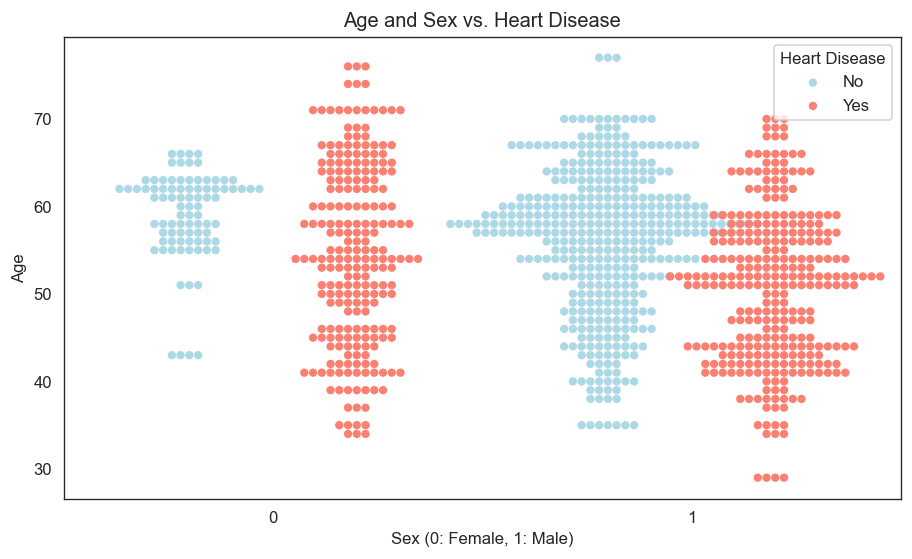

In [11]:
# Define a custom color palette for 'No' and 'Yes' classes
custom_palette = {0: "lightblue", 1: "salmon"}

plt.figure(figsize=(9, 5),dpi=120)
sns.swarmplot(x='sex', y='age', hue='heart_disease', data=hd, palette=custom_palette, dodge=True, size=5)
plt.xlabel('Sex (0: Female, 1: Male)')
plt.ylabel('Age')
plt.title('Age and Sex vs. Heart Disease')
plt.legend(title='Heart Disease', loc='upper right', labels=['No', 'Yes'])
plt.show()

- Female over 60 yrs are more at risk of heart disease in the data.
- Female less than 40/50 years are at less risk of heart disease in the data.
- However, Male less than 40/50 years are more at risk.

# Scatter Plot of Resting Blood Pressure vs. Cholesterol

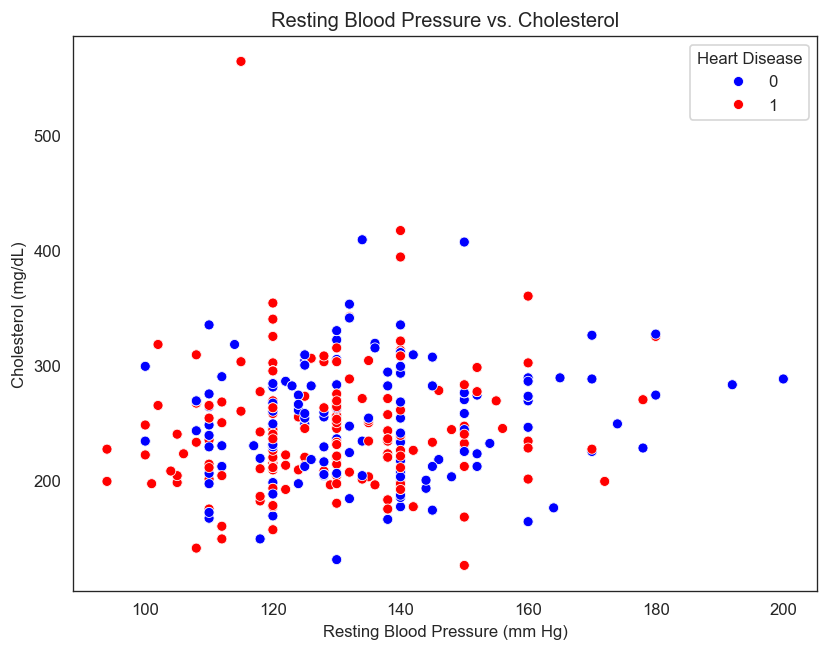

In [13]:
custom_palette = {0: "blue", 1: "red"}
plt.figure(figsize=(8, 6),dpi=120)
sns.scatterplot(x='resting_blood_pressure', y='cholesterol', hue='heart_disease', data=hd, palette=custom_palette)
plt.xlabel('Resting Blood Pressure (mm Hg)')
plt.ylabel('Cholesterol (mg/dL)')
plt.title('Resting Blood Pressure vs. Cholesterol')
plt.legend(title='Heart Disease', loc='upper right')
plt.show()

- Resting Blood Pressure Values of > 120 are abnormal and can progress to heart failure from the plot, which makes sense.
- High value of Cholesterol also signifies risk of heart disease.

# Detecting Outliers with Inter Quartile Range

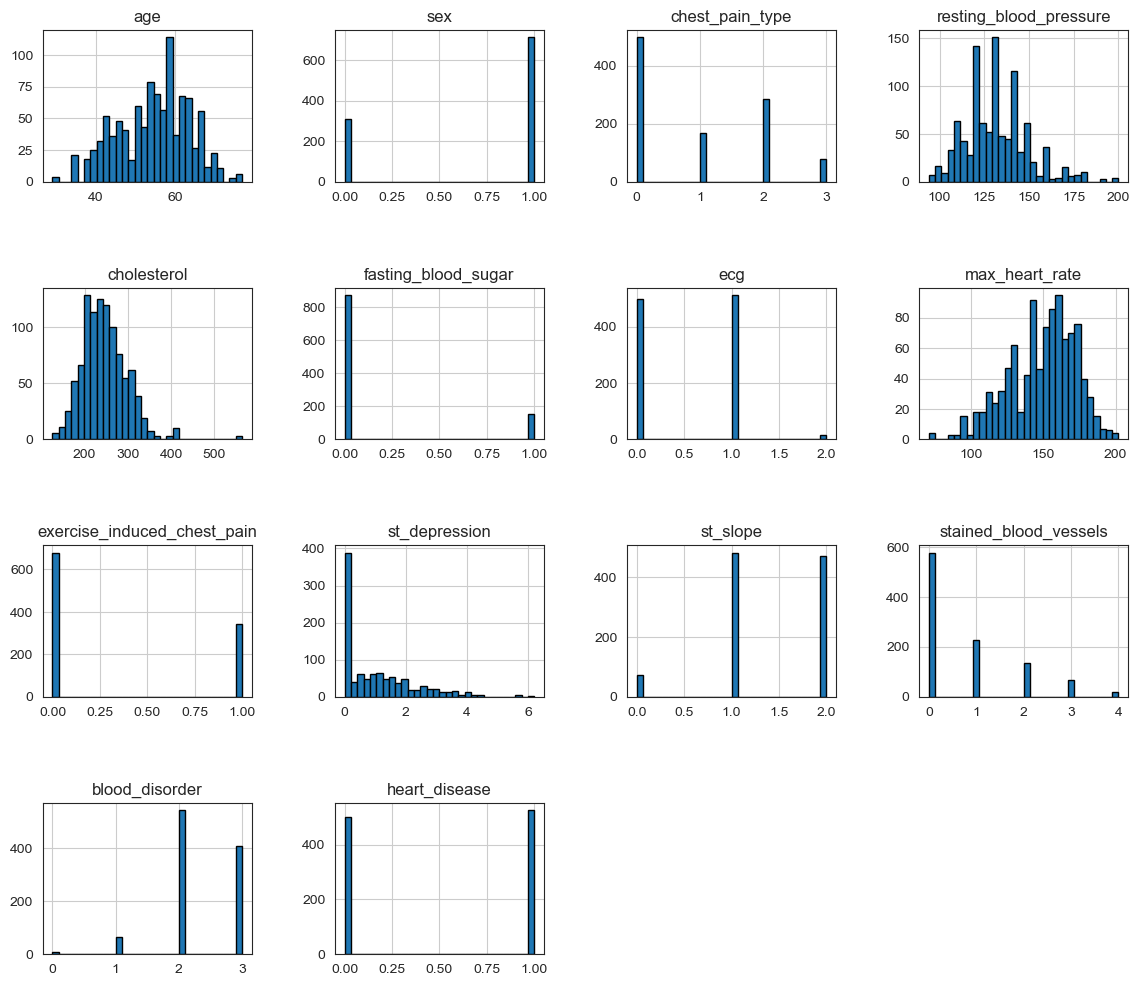

In [14]:
#Check the distribution of all variables
hd.hist(figsize=(14, 12), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)

We are going to investigate for outliers in:cholesterol, max_heart_rate,st_depression,resting_bood_pressure for outliers since they appear skewed.

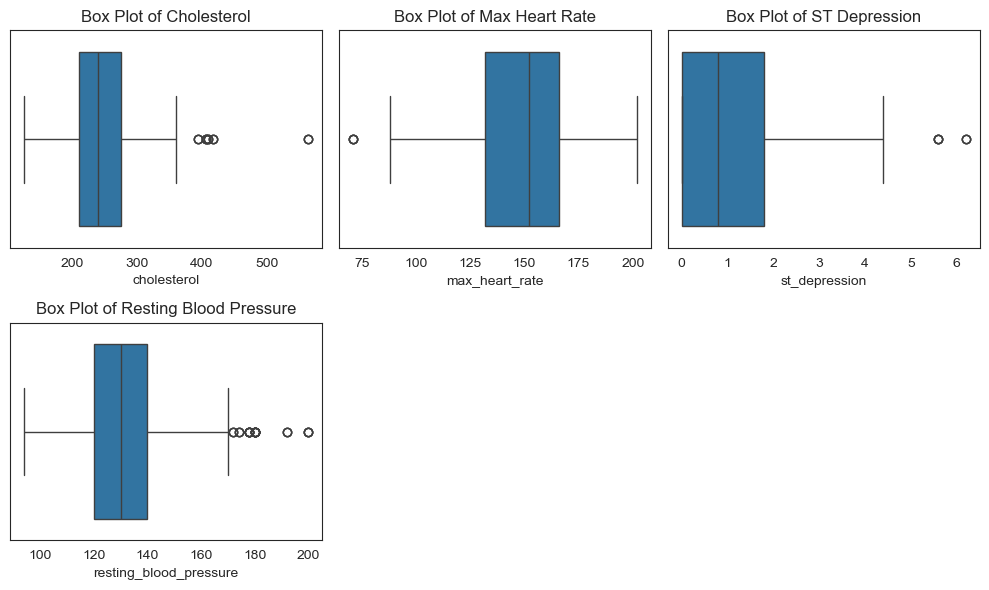

In [15]:
# Plot the box plots of outlier prone features

plt.figure(figsize=(10, 6))

# Box plot for 'cholesterol'
plt.subplot(2, 3, 1)
sns.boxplot(x='cholesterol', data=hd)
plt.title("Box Plot of Cholesterol")

# Box plot for 'max_heart_rate'
plt.subplot(2, 3, 2)
sns.boxplot(x='max_heart_rate', data=hd)
plt.title("Box Plot of Max Heart Rate")

# Box plot for 'st_depression'
plt.subplot(2, 3, 3)
sns.boxplot(x='st_depression', data=hd)
plt.title("Box Plot of ST Depression")

# Box plot for 'resting_blood_sugar'
plt.subplot(2, 3, 4)
sns.boxplot(x='resting_blood_pressure', data=hd)
plt.title("Box Plot of Resting Blood Pressure")

plt.tight_layout() # Adjust the spacing between subplots
plt.show()

# Outlier Removal from the Data

In [16]:
#Define a function to use IQR for outliers removal
def find_boundaries(df, variables, distance):
    boundaries = {}  # Dictionary to store the boundaries for each variable

    for variable in variables:
        # Interquartile Range (IQR) of the variable
        IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

        # lower boundary
        lower_boundary = df[variable].quantile(0.25) - (IQR * distance)

        # upper boundary
        upper_boundary = df[variable].quantile(0.75) + (IQR * distance)

        boundaries[variable] = (upper_boundary, lower_boundary)

    return boundaries

In [17]:
variables_to_check = ['cholesterol', 'max_heart_rate', 'st_depression', 'resting_blood_pressure']
outlier_boundaries = find_boundaries(hd, variables_to_check, distance=1.5)

# Print the outlier boundaries for each variable
for variable, (upper, lower) in outlier_boundaries.items():
    print(f"Variable: {variable}, Upper Boundary: {upper}, Lower Boundary: {lower}")

Variable: cholesterol, Upper Boundary: 371.0, Lower Boundary: 115.0
Variable: max_heart_rate, Upper Boundary: 217.0, Lower Boundary: 81.0
Variable: st_depression, Upper Boundary: 4.5, Lower Boundary: -2.7
Variable: resting_blood_pressure, Upper Boundary: 170.0, Lower Boundary: 90.0


In [18]:
# Create a boolean vector to flag outliers for each variable
outliers = {}
for variable in variables_to_check:
    outliers[variable] = np.where(
        (hd[variable] > outlier_boundaries[variable][0]) |
        (hd[variable] < outlier_boundaries[variable][1]),   
        True,                                               
        False                                                    
    )

# Print the first few elements of the outlier flags for each variable
for variable in variables_to_check:
    print(f"Outliers for {variable}:")
    print(outliers[variable][:10]) 
    print("----------------------")

Outliers for cholesterol:
[False False False False False False False False False False]
----------------------
Outliers for max_heart_rate:
[False False False False False False False False False False]
----------------------
Outliers for st_depression:
[False False False False False False False False False False]
----------------------
Outliers for resting_blood_pressure:
[False False False False False False False False False False]
----------------------


In [112]:
outliers

{'cholesterol': array([False, False, False, ..., False, False, False]),
 'max_heart_rate': array([False, False, False, ..., False, False, False]),
 'st_depression': array([False, False, False, ..., False, False, False]),
 'resting_blood_pressure': array([False, False, False, ..., False, False, False])}

The outliers dictionary will contain a boolean vector for each variable, where True indicates an outlier and False indicates an observation within the boundaries.

In [19]:
# Combine the outlier flags for all variables using logical OR (|)
all_outliers = np.logical_or.reduce([outliers[variable] for variable in variables_to_check])

# Remove the rows with outliers from the DataFrame 
hd_without_outliers = hd.loc[~all_outliers]
#hd.drop(hd.index[all_outliers], inplace=True)

# Print the shape of the DataFrame after removing outliers
print("Shape of Heart Disease Dataset after removing outliers:", hd_without_outliers.shape)

Shape of Heart Disease Dataset after removing outliers: (968, 14)


In [20]:
hd_without_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 968 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          968 non-null    int64  
 1   sex                          968 non-null    int64  
 2   chest_pain_type              968 non-null    int64  
 3   resting_blood_pressure       968 non-null    int64  
 4   cholesterol                  968 non-null    int64  
 5   fasting_blood_sugar          968 non-null    int64  
 6   ecg                          968 non-null    int64  
 7   max_heart_rate               968 non-null    int64  
 8   exercise_induced_chest_pain  968 non-null    int64  
 9   st_depression                968 non-null    float64
 10  st_slope                     968 non-null    int64  
 11  stained_blood_vessels        968 non-null    int64  
 12  blood_disorder               968 non-null    int64  
 13  heart_disease           

In [22]:
# Get the distribution of the response variable (target)
print(hd_without_outliers.groupby('heart_disease').size())

heart_disease
0    460
1    508
dtype: int64


- Response variable, No disease = 0, Heart Disease Present = 1.

- of the 968 data points, 460 instances have no disease, while 508 instances have heart disease.

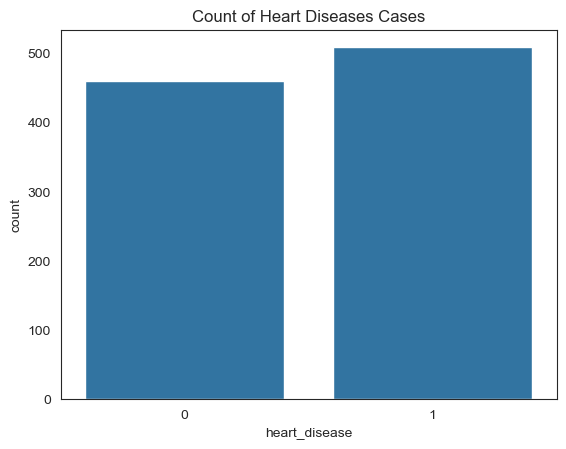

In [24]:
# Get the visualization
#sns.countplot(hd_without_outliers['heart_disease'],label="Count")
sns.countplot(data=hd_without_outliers, x= 'heart_disease')
plt.title ('Count of Heart Diseases Cases')
plt.show()

# Model Building

In [25]:
hd_without_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 968 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          968 non-null    int64  
 1   sex                          968 non-null    int64  
 2   chest_pain_type              968 non-null    int64  
 3   resting_blood_pressure       968 non-null    int64  
 4   cholesterol                  968 non-null    int64  
 5   fasting_blood_sugar          968 non-null    int64  
 6   ecg                          968 non-null    int64  
 7   max_heart_rate               968 non-null    int64  
 8   exercise_induced_chest_pain  968 non-null    int64  
 9   st_depression                968 non-null    float64
 10  st_slope                     968 non-null    int64  
 11  stained_blood_vessels        968 non-null    int64  
 12  blood_disorder               968 non-null    int64  
 13  heart_disease           

In [26]:
X_train, X_test, y_train, y_test = train_test_split(hd_without_outliers.loc[:, hd_without_outliers.columns != 'heart_disease'], hd_without_outliers['heart_disease'], stratify=hd_without_outliers['heart_disease'], random_state=123)

stratify=hd_without_outliers ['heart_disease'], the function will split the data in a way that preserves the same proportion of positive (1) and negative (0) values of the 'heart_disease' column in both the training and testing datasets.

In [27]:
y_train.shape

(726,)

In [28]:
y_train.value_counts()

heart_disease
1    381
0    345
Name: count, dtype: int64

In [29]:
y_test.value_counts()

heart_disease
1    127
0    115
Name: count, dtype: int64

In [30]:
y_test.shape

(242,)

In [31]:
y_train

525     1
303     0
1006    1
692     0
712     1
       ..
31      1
79      1
918     0
180     0
557     1
Name: heart_disease, Length: 726, dtype: int64

In [32]:
X_train

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,ecg,max_heart_rate,exercise_induced_chest_pain,st_depression,st_slope,stained_blood_vessels,blood_disorder
525,51,0,2,130,256,0,0,149,0,0.5,2,0,2
303,60,1,0,145,282,0,0,142,1,2.8,1,2,3
1006,58,1,2,140,211,1,0,165,0,0.0,2,0,2
692,53,1,0,140,203,1,0,155,1,3.1,0,0,3
712,45,0,1,112,160,0,1,138,0,0.0,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2
79,52,1,1,134,201,0,1,158,0,0.8,2,1,2
918,59,1,3,134,204,0,1,162,0,0.8,2,2,2
180,63,1,0,140,187,0,0,144,1,4.0,2,2,3


In [33]:
X_test

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,ecg,max_heart_rate,exercise_induced_chest_pain,st_depression,st_slope,stained_blood_vessels,blood_disorder
457,39,0,2,138,220,0,1,152,0,0.0,1,0,2
857,43,1,0,115,303,0,1,181,0,1.2,1,0,2
70,59,1,0,170,326,0,0,140,1,3.4,0,0,3
48,66,0,2,146,278,0,0,152,0,0.0,1,1,2
274,66,1,0,160,228,0,0,138,0,2.3,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,60,0,0,150,258,0,0,157,0,2.6,1,2,3
240,54,0,1,132,288,1,0,159,1,0.0,2,1,2
141,63,0,0,124,197,0,1,136,1,0.0,1,0,2
675,58,1,0,100,234,0,1,156,0,0.1,2,1,3


# Scaling the Dataset

In [34]:
# Separate numerical features and categorical features
numerical_features = ['age', 'resting_blood_pressure', 'cholesterol', 'max_heart_rate', 'st_depression']

categorical_features = ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'ecg', 'exercise_induced_chest_pain', 
                        'st_slope', 'stained_blood_vessels', 'blood_disorder']

# StandardScaler instance
scaler = StandardScaler()

# Fit scaler on the training numerical features and transform the training data
X_train_scaled = X_train.copy()  
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])

# Use learned scaling parameters to transform the testing data
X_test_scaled = X_test.copy()   
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

In [35]:
X_train_scaled.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,ecg,max_heart_rate,exercise_induced_chest_pain,st_depression,st_slope,stained_blood_vessels,blood_disorder
525,-0.333055,0,2,0.023841,0.292023,0,0,-0.025533,0,-0.466282,2,0,2
303,0.648532,1,0,1.003591,0.864782,0,0,-0.330845,1,1.669789,1,2,3
1006,0.430402,1,2,0.677008,-0.699290,1,0,0.672323,0,-0.930645,2,0,2
692,-0.114924,1,0,0.677008,-0.875523,1,0,0.236163,1,1.948407,0,0,3
712,-0.987446,0,1,-1.151858,-1.822778,0,1,-0.505309,0,-0.930645,1,0,2


In [36]:
# View the scaled X_test
X_test_scaled.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,ecg,max_heart_rate,exercise_induced_chest_pain,st_depression,st_slope,stained_blood_vessels,blood_disorder
457,-1.641837,0,2,0.546375,-0.501027,0,1,0.105315,0,-0.930645,1,0,2
857,-1.205576,1,0,-0.955908,1.327395,0,1,1.370179,0,0.183826,1,0,2
70,0.539467,1,0,2.636508,1.834066,0,0,-0.418077,1,2.227025,0,0,3
48,1.302924,0,2,1.068908,0.776665,0,0,0.105315,0,-0.930645,1,1,2
274,1.302924,1,0,1.983341,-0.324794,0,0,-0.505309,0,1.205426,2,0,1


# Using K-Nearest Neighbors (KNN)

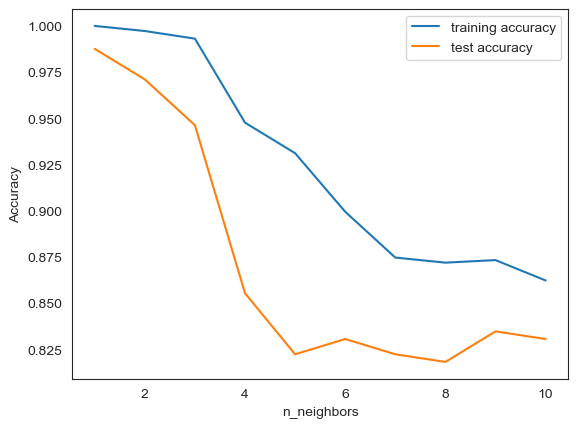

In [37]:
from sklearn.neighbors import KNeighborsClassifier

training_accuracy = []
test_accuracy = []
# try n_neighbors from 1 to 10
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    # build the model
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train_scaled, y_train)
    # record training set accuracy
    training_accuracy.append(knn.score(X_train_scaled, y_train))
    # record test set accuracy
    test_accuracy.append(knn.score(X_test_scaled, y_test))

plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()
plt.savefig('knn_compare_model')

If we choose one single nearest neighbor, the prediction on the training and test set is perfect. 
But when more neighbors are considered, the training and test accuracy begin to drop, 
indicating that using a single nearest neighbor leads to models that are overfitting.

Therefore from the chat above, the best performance is somewhere around 3 neighbors.

In [38]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

#The accuracy is the proportion of correctly classified data points in the train and test sets.
print('Accuracy of K-NN classifier on training set: {:.2f}'.format(knn.score(X_train_scaled, y_train)))
print('Accuracy of K-NN classifier on test set: {:.2f}'.format(knn.score(X_test_scaled, y_test)))

Accuracy of K-NN classifier on training set: 0.99
Accuracy of K-NN classifier on test set: 0.95


# Training KNN with Cross Validation

- Using cross-validation helps to ensure that our model's performance is not over-optimized on a particular training-test split and that it can generalize well to unseen data.

- It also provides insight into the stability of our model's performance across different subsets of data, giving us more confidence in its predictions.

In [39]:
knn = KNeighborsClassifier(n_neighbors=3)

# k-fold cross-validation with k=5
k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

# The cross_val_score function splits the training set into 5 subsets (folds) 
# and trains the Knn model on each fold while evaluating its accuracy. 
cv_scores_train = cross_val_score(knn, X_train_scaled, y_train, cv=k_fold, scoring='accuracy')
average_accuracy_train = cv_scores_train.mean()

# Training KNN model
knn.fit(X_train_scaled, y_train)

# Calculate the accuracy on the test set
test_accuracy = knn.score(X_test_scaled, y_test)

# Print the results
print('Average accuracy of K-NN classifier on training set: {:.2f}'.format(average_accuracy_train))
print('Accuracy of K-NN classifier on test set: {:.2f}'.format(test_accuracy))

Average accuracy of K-NN classifier on training set: 0.88
Accuracy of K-NN classifier on test set: 0.95


Training KNN with Cross Validation eliminated the overfitting.

In [41]:
#Predict test data
y_pred_knn=knn.predict(X_test_scaled)

In [42]:
y_pred_knn

array([1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0])

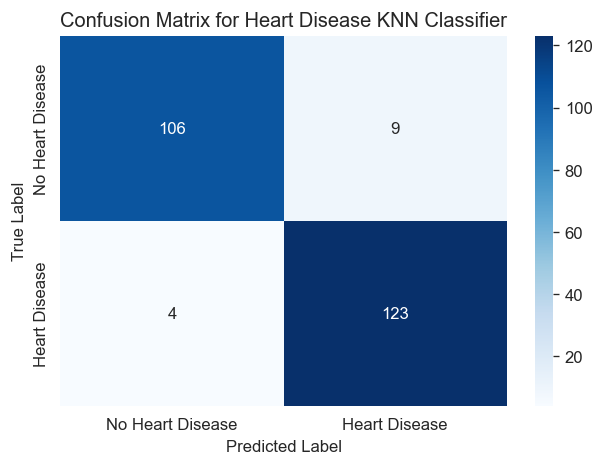

In [43]:
# Generate the confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Create a DataFrame from the confusion matrix for better visualization
labels = ['No Heart Disease', 'Heart Disease']
cm_df_knn = pd.DataFrame(cm_knn, index=labels, columns=labels)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4),dpi = 120)
sns.heatmap(cm_df_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Heart Disease KNN Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()

# MODEL EVALUATION FOR KNN

- Accuracy: Accuracy helps us to know if we are correctly identifying heart disease cases (positive samples) and non-heart disease cases (negative samples). However it does not reveal the impact of misclassification.

The accuracy metric considers both false positives and false negatives as errors but treats them equally when calculating the proportion of correctly classified samples. This means that each misclassification contributes equally to the overall accuracy score.

However, the consequences of false positives and false negatives in heart disease prediction are quite different:

- False Positives: Misclassifying a healthy individual as having heart disease (false positive) may lead to unnecessary medical tests, treatments, or stress for the person, which can be undesirable and potentially costly.

- False Negatives: Misclassifying a person with heart disease as not having it (false negative) could be more serious. It means that the individual might not receive timely medical attention or necessary interventions, potentially leading to delayed treatment and adverse health outcomes.

# Other Evaluation Metrics ( Considers trade-offs between false positives and false negatives)

- Precision: Answers out of all the examples that are predicted as having heart disease, how many are really having heart diseas?

- Recall (Sensitivity or True Positive Rate): Out of all those having heart disease, how many are predicted as having heart disease?

- F1 Score: The F1 score is the harmonic mean of precision and recall and provides a balanced measure between them.

- support: Provides information about the distribution of samples across different classes used in testing the model for prediction.

In [44]:
# Calculate Evaluation Metrics
classification_report_knn = metrics.classification_report(y_test, y_pred_knn)
print("Classification Report for KNN:")
print(classification_report_knn)

Classification Report for KNN:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       115
           1       0.93      0.97      0.95       127

    accuracy                           0.95       242
   macro avg       0.95      0.95      0.95       242
weighted avg       0.95      0.95      0.95       242



### KNN Results Interpretation

- Precision: For class 0 (no disease), the precision is 0.96, meaning that out of all the instances the model predicted as not having heart disease, 96% were correct. For class 1 (heart disease present), the precision is 0.93, indicating that out of all the instances the model predicted as having heart disease, 93% were correct.

- Recall: For class 0, the recall is 0.92, meaning that the model correctly identified 92% of the actual instances with no heart disease. For class 1, the recall is 0.97, indicating that the model correctly identified 97% of the actual instances with heart disease.

- For class 0, the F1-score is 0.94, which takes into account the balance between precision and recall for this class. For class 1, the F1-score is 0.95, showing the balance between precision and recall for heart disease predictions.

- Support: Support refers to the number of samples in each class. In this case, there are 115 samples with no heart disease (class 0) and 127 samples with heart disease (class 1).

# Explainability of Model with ELI5 - Feature Importance

What features does a model think are important? Which features might have a greater impact on the model predictions than others? This concept is called feature importance and Permutation Importance is a technique used widely for calculating feature importance. It helps us to see when our model produces counterintuitive results, and it helps to show the others when our model is working as we'd hope.

Permutation Importance works for many scikit-learn estimators. The idea is simple:

- Randomly permutate or shuffle one column in the validation dataset leaving all the other columns intact.
- A feature is considered “important” if the model's accuracy drops a lot and causes an increase in error.
- On the other hand, a feature is considered “unimportant” if shuffling its values don't affect the model's accuracy.

Permutation Importance helps to provide a high-level overview of the model and thereby aids in understanding which features are more important than the others.

In [45]:
perm = PermutationImportance(knn, random_state=1).fit(X_test_scaled, y_test)

In [46]:
perm

,estimator,KNeighborsCla...n_neighbors=3)
,scoring,None
,n_iter,5
,random_state,1
,cv,'prefit'
,refit,True
,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2


In [138]:
perm.results_

[array([0.02892562, 0.01652893, 0.07438017, 0.03305785, 0.02066116,
        0.        , 0.03305785, 0.05785124, 0.01652893, 0.01652893,
        0.        , 0.05371901, 0.02479339]),
 array([0.02892562, 0.02066116, 0.08677686, 0.02479339, 0.02479339,
        0.00413223, 0.01239669, 0.06198347, 0.02066116, 0.03305785,
        0.        , 0.05371901, 0.02892562]),
 array([0.02892562, 0.00413223, 0.07024793, 0.05371901, 0.02892562,
        0.00826446, 0.00826446, 0.03719008, 0.02066116, 0.04132231,
        0.00826446, 0.08677686, 0.02479339]),
 array([ 0.04132231,  0.02066116,  0.07024793,  0.04958678,  0.02892562,
         0.00413223,  0.02066116,  0.02479339,  0.01239669,  0.03305785,
        -0.01652893,  0.07024793,  0.01652893]),
 array([0.04132231, 0.00826446, 0.0785124 , 0.05371901, 0.01652893,
        0.        , 0.01239669, 0.02892562, 0.01652893, 0.02066116,
        0.        , 0.05785124, 0.03305785])]

The perm.results_ contains the permutation importances obtained through the permutation importance calculation for each feature.

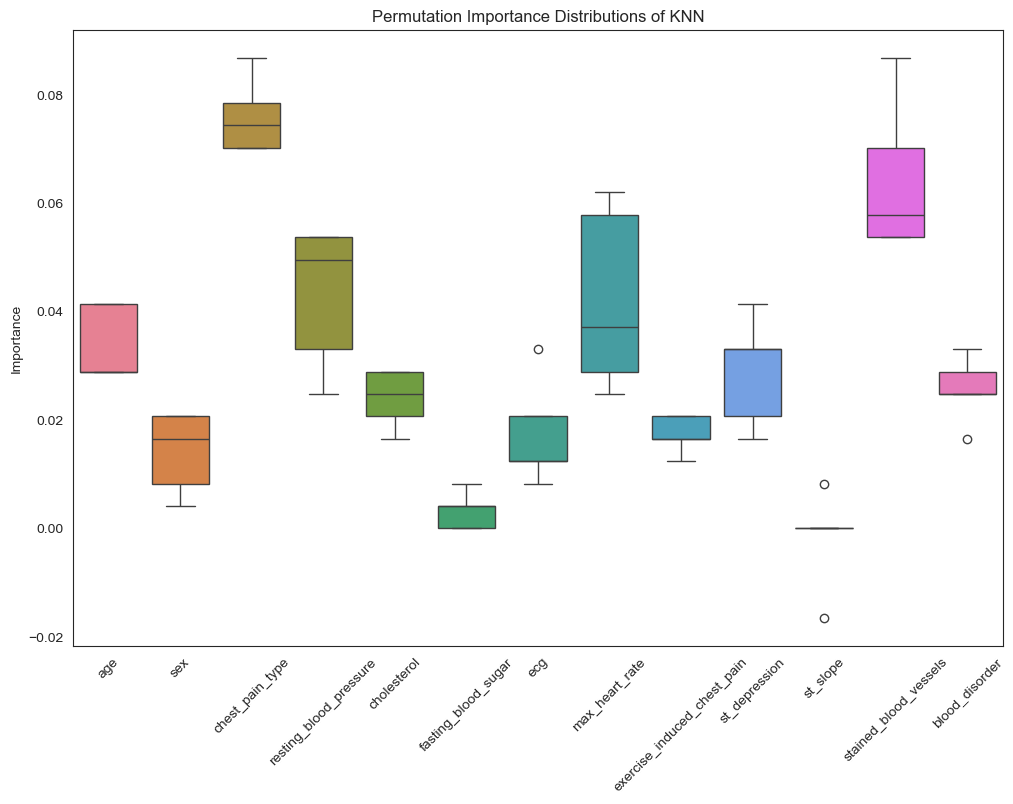

In [47]:
#pd.DataFrame.iteritems = pd.DataFrame.items

# Create DataFrame
perm_feat_imp_knn = pd.DataFrame(
    data=perm.results_,
    columns=X_test_scaled.columns.tolist()
)

# Plot
plt.figure(figsize=(12, 8))
sns.boxplot(data=perm_feat_imp_knn)

plt.title('Permutation Importance Distributions of KNN')
plt.ylabel('Importance')
plt.xticks(rotation=45)

plt.show()

### Interpretation of KNN Feature Importance

- The features at the top are most important and at the bottom, the least. 

- For this example, "chest_pain_type" is the most important feature and decides whether a person have heart_disease, which also makes sense.

- Chest pain is often associated with heart disease, and Angina is a chest pain that's often a symptom of coronary artery disease (heart disease).

- 'stained_blood_vessels' is also an important feature, which makes sense.Blood vessels with observed plaque build-up can lead to coronary artery disease, angina, heart attack or potentially heart failure.

# Using Logistic Regression with Cross Validation

In [48]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()

# k-fold cross-validation with k=5
k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_train = cross_val_score(logreg, X_train_scaled, y_train, cv=k_fold, scoring='accuracy')
average_accuracy_train = cv_scores_train.mean()


logreg.fit(X_train_scaled, y_train)
test_accuracy = logreg.score(X_test_scaled, y_test)

print('Average accuracy of Logistic Regression on training set: {:.2f}'.format(average_accuracy_train))
print('Accuracy of Logistic Regression on test set: {:.2f}'.format(test_accuracy))

Average accuracy of Logistic Regression on training set: 0.83
Accuracy of Logistic Regression on test set: 0.86


In [49]:
#Predict test data
y_pred_logreg=logreg.predict(X_test_scaled)

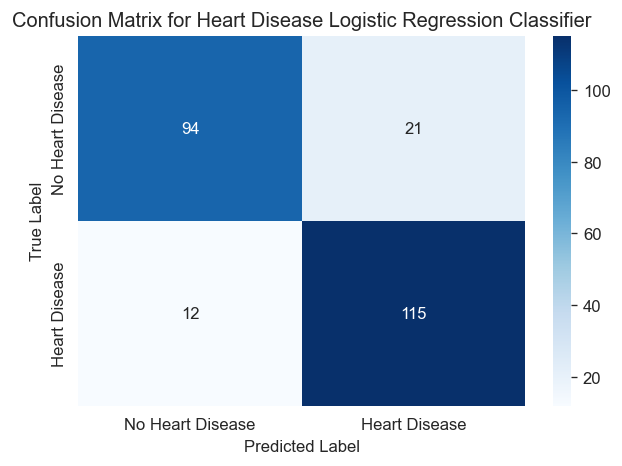

In [50]:
# Generate the confusion matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

# Create a DataFrame from the confusion matrix for better visualization
labels = ['No Heart Disease', 'Heart Disease']
cm_df_logreg = pd.DataFrame(cm_logreg, index=labels, columns=labels)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4),dpi = 120)
sns.heatmap(cm_df_logreg, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Heart Disease Logistic Regression Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()

In [51]:
# Calculate Evaluation Metrics
classification_report_logreg = metrics.classification_report(y_test, y_pred_logreg)
print("Classification Report for Logistic Regression:")
print(classification_report_logreg)

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.89      0.82      0.85       115
           1       0.85      0.91      0.87       127

    accuracy                           0.86       242
   macro avg       0.87      0.86      0.86       242
weighted avg       0.87      0.86      0.86       242



In [52]:
perm_logreg = PermutationImportance(logreg, random_state=1).fit(X_test_scaled, y_test)

<Figure size 1000x600 with 0 Axes>

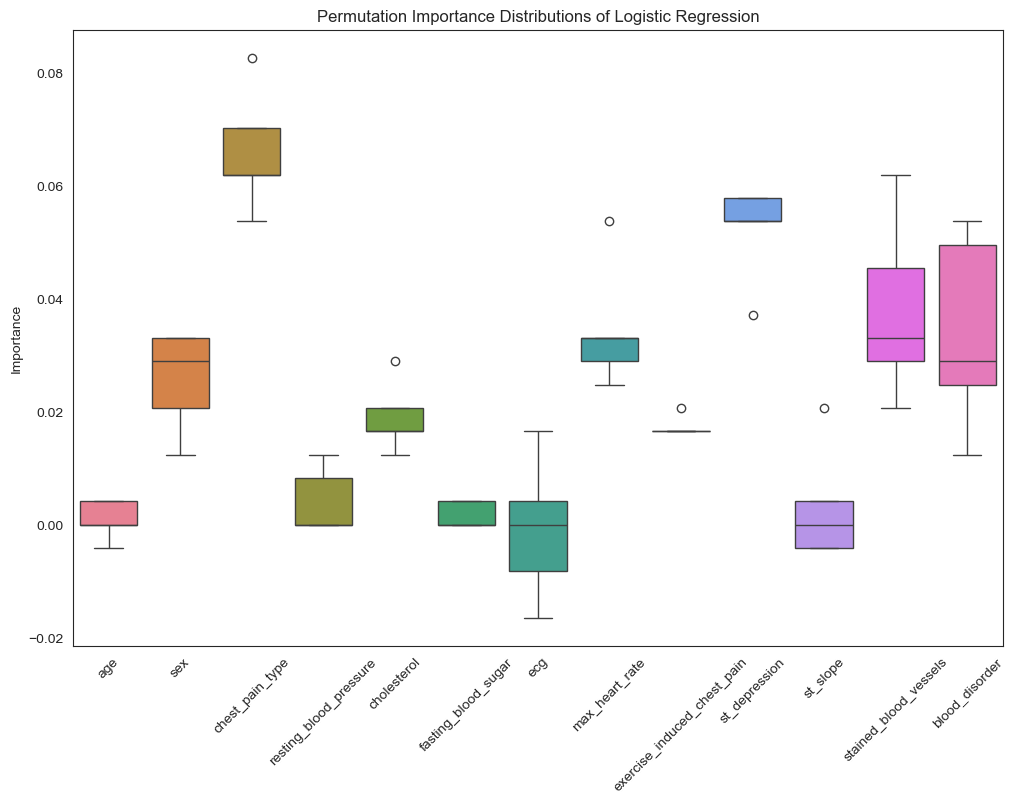

In [53]:
#Plotting the distributions
plt.figure(figsize=(10, 6))
perm_feat_imp_logreg = pd.DataFrame(data=perm_logreg.results_,
                                      columns=X_test_scaled.columns.tolist())
plt.figure(figsize=(12, 8)) 

# Plot the distributions of feature importances using a boxplot
sns.boxplot(data=perm_feat_imp_logreg)

# Set plot title and labels
plt.title('Permutation Importance Distributions of Logistic Regression')
plt.ylabel('Importance')

# Display the plot
plt.xticks(rotation=45)
plt.show()

### Interpretation of Logistic Regression Feature Importance

- For Logistic Regression, "chest_pain_type" is also the most important feature and decides whether a person have heart_disease, which also makes sense. Angina is a chest pain that's often a symptom of coronary artery disease (heart disease).

# Using Random Forest with Cross Validation - BEST MODEL

In [54]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest classifier with hyperparameter tunings
rf_classifier = RandomForestClassifier(n_estimators=100,random_state=0, max_depth=6)

k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_train = cross_val_score(rf_classifier, X_train_scaled, y_train, cv=k_fold, scoring='accuracy')
average_accuracy_train = cv_scores_train.mean()

rf_classifier.fit(X_train_scaled, y_train)

test_accuracy = rf_classifier.score(X_test_scaled, y_test)

print('Average accuracy of Random Forest classifier on training set: {:.3f}'.format(average_accuracy_train))
print('Accuracy of Random Forest classifier on test set: {:.3f}'.format(test_accuracy))

Average accuracy of Random Forest classifier on training set: 0.964
Accuracy of Random Forest classifier on test set: 0.983


In [55]:
#Predict test data
y_pred_rf=rf_classifier.predict(X_test_scaled)

In [56]:
y_pred_rf

array([1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0])

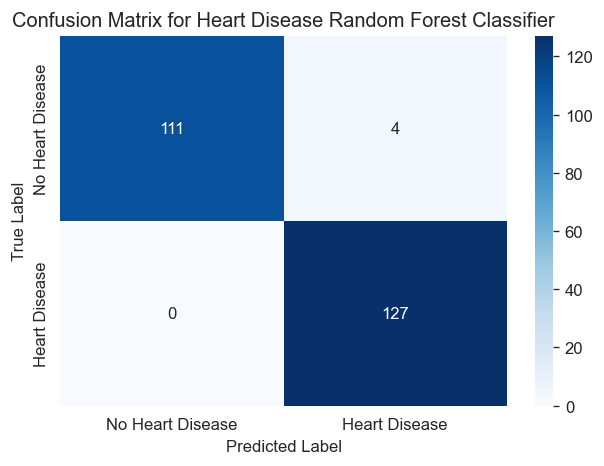

In [57]:
# Generate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Create a DataFrame from the confusion matrix for better visualization
labels = ['No Heart Disease', 'Heart Disease']
cm_df_rf = pd.DataFrame(cm_rf, index=labels, columns=labels)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4),dpi = 120)
sns.heatmap(cm_df_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Heart Disease Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()

In [59]:
# Calculate Evaluation Metrics
classification_report_rf = metrics.classification_report(y_test, y_pred_rf)
print("Classification Report for Random Forest:")
print(classification_report_rf)

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       115
           1       0.97      1.00      0.98       127

    accuracy                           0.98       242
   macro avg       0.98      0.98      0.98       242
weighted avg       0.98      0.98      0.98       242



### Random Forest Results Interpretation

- Precision: For class 0 (no disease), the precision is 1.00, meaning that out of all the instances the model predicted as not having heart disease, the model is 100% correct. For class 1 (heart disease present), the precision is 0.97, indicating that out of all the instances the model predicted as having heart disease, 97% were correct.


- Recall: For class 0, the recall is 0.97, meaning that the model correctly identified 97% of the actual instances with no heart disease. For class 1, the recall is 1.00, indicating that the model correctly identified 100% of the actual instances with heart disease.


- For class 0, the F1-score is 0.98, which takes into account the balance between precision and recall for this class. For class 1, the F1-score is 0.98, showing the balance between precision and recall for heart disease predictions.


- Support: Support refers to the number of samples in each class. In this case, there are 115 samples with no heart disease (class 0) and 127 samples with heart disease (class 1).

In [61]:
perm_rf = PermutationImportance(rf_classifier, random_state=1).fit(X_test_scaled, y_test)

In [62]:
feature_importance = pd.DataFrame({
    'feature': X_test_scaled.columns,
    'importance': perm_rf.feature_importances_
})

# Sort
feature_importance = feature_importance.sort_values(by='importance', ascending=False)

print(feature_importance)

                        feature  importance
11        stained_blood_vessels    0.091736
2               chest_pain_type    0.072727
12               blood_disorder    0.038017
9                 st_depression    0.032231
4                   cholesterol    0.028099
0                           age    0.027273
10                     st_slope    0.021488
1                           sex    0.016529
7                max_heart_rate    0.013223
3        resting_blood_pressure    0.012397
8   exercise_induced_chest_pain    0.010744
6                           ecg    0.002479
5           fasting_blood_sugar    0.000000


<Figure size 1000x600 with 0 Axes>

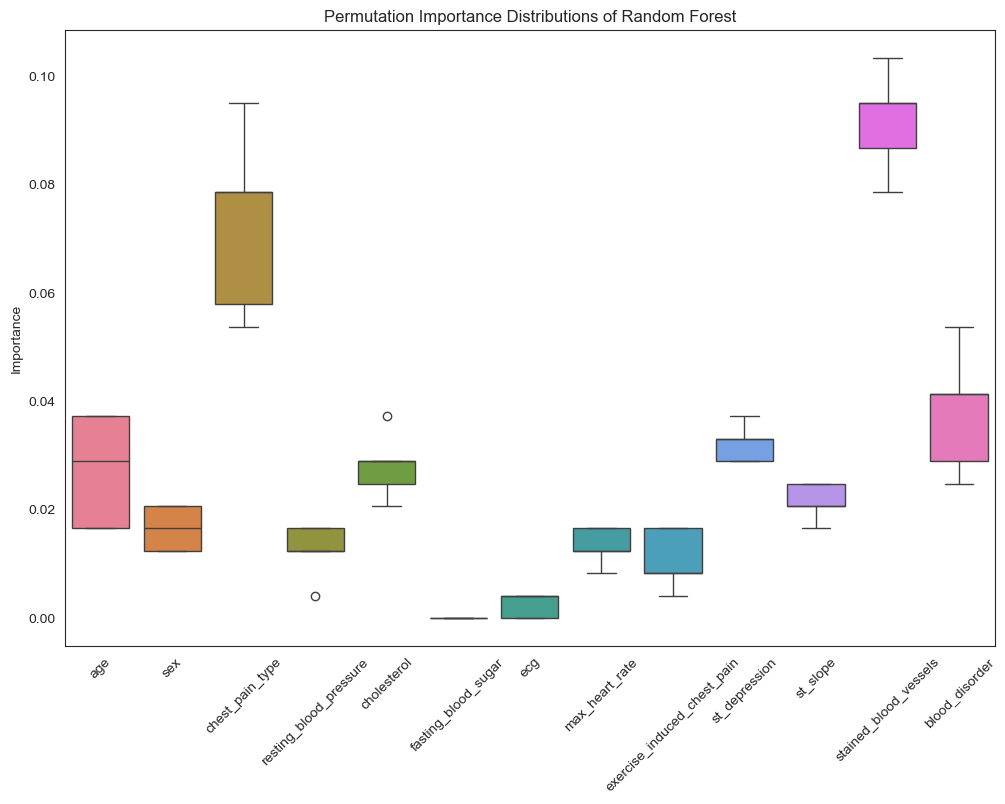

In [63]:
#Plotting the distributions
plt.figure(figsize=(10, 6))
perm_feat_imp_rf = pd.DataFrame(data=perm_rf.results_,
                                      columns=X_test_scaled.columns.tolist())
plt.figure(figsize=(12, 8)) 

# Plot the distributions of feature importances using a boxplot
sns.boxplot(data=perm_feat_imp_rf)

# Set plot title and labels
plt.title('Permutation Importance Distributions of Random Forest')
plt.ylabel('Importance')

# Display the plot
plt.xticks(rotation=45)
plt.show()

## Interpretation of Random Forest Feature Importance

The features at the top are most important and at the bottom, the least.

- For Random Forest, 'stained_blood_vessels' is the most important feature, which makes sense.Blood vessels with observed plaque build-up can lead to coronary artery disease, angina, heart attack or potentially heart failure.

- Chest pain, also acknowledged by other algorithms is also important, it is often associated with heart disease, and Angina is a chest pain that's often a symptom of coronary artery disease.


# Saving and Re-Using the Random Forest Model for New Patient Prediction/Diagnosis

In [64]:
# ================================
# Save model, scaler, and features
# ================================

import joblib

rf_pipeline = {
    "model": rf_classifier,
    "scaler": scaler,
    "features": X_train.columns.tolist()  # VERY IMPORTANT
}

joblib.dump(rf_pipeline, "rf_pipeline.pkl")

print("Model, scaler, and feature list saved successfully!")

Model, scaler, and feature list saved successfully!


In [65]:
# Load and use it for prediction
rf_pipeline = joblib.load("rf_pipeline.pkl")

model = rf_pipeline["model"]
scaler = rf_pipeline["scaler"]
features = rf_pipeline["features"]

In [66]:
X_train.columns.tolist()

['age',
 'sex',
 'chest_pain_type',
 'resting_blood_pressure',
 'cholesterol',
 'fasting_blood_sugar',
 'ecg',
 'max_heart_rate',
 'exercise_induced_chest_pain',
 'st_depression',
 'st_slope',
 'stained_blood_vessels',
 'blood_disorder']

In [67]:
new_heart_data = [[
    54,     # age
    1,      # sex (1 = male, 0 = female)
    2,      # chest_pain_type (e.g., 0–3)
    130,    # resting_blood_pressure
    246,    # cholesterol
    0,      # fasting_blood_sugar (0 = normal, 1 = high)
    1,      # ecg (0–2)
    150,    # max_heart_rate
    0,      # exercise_induced_chest_pain (0 = no, 1 = yes)
    1.2,    # st_depression
    1,      # st_slope (0–2)
    0,      # stained_blood_vessels (0–3)
    2       # blood_disorder (e.g., 1–3)
]]

In [71]:
new_data = pd.DataFrame(new_heart_data, columns=X_train.columns.tolist())

In [72]:
new_data

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,ecg,max_heart_rate,exercise_induced_chest_pain,st_depression,st_slope,stained_blood_vessels,blood_disorder
0,54,1,2,130,246,0,1,150,0,1.2,1,0,2


In [74]:
# Predict probability of Heart Disease
probability = model.predict_proba(new_data)

# Extract values
# [0] → first row (your single patient) e.g also asssuming you have a second patient it will be [1].
# [0] → class 0 and 1 - no heart disease and heart disease.
prob_no_heart_disease = probability[0][0]
prob_heart_disease = probability[0][1]

print(f"Probability of No Disease: {prob_no_heart_disease:.2f}")
print(f"Probability of Disease: {prob_heart_disease:.2f}")

Probability of No Disease: 0.34
Probability of Disease: 0.66


# What your model is doing internally

For Random Forest:

Each tree votes for a class. So the Probability is the fraction of trees voting for each class.

Example:

83 trees → disease

17 trees → no disease

👉 Probability = [0.83, 0.17]

# Final Recommendations

### Overall, the Random Forest classifier demonstrates excellent performance in predicting the presence or absence of "heart disease." 

- It accurately identifies cases with heart disease (class 1, Recall) - In other words, when the model encounters an individual with heart disease, it correctly classifies them as having heart disease almost every time. This is especially important in cases where the consequences of false negatives (misclassifying someone with heart disease as not having it) can be severe. A high Recall ensures that the model has a low tendency to miss identifying individuals with heart disease, reducing the chances of false negatives.

- It can also correctly classifies most instances without heart disease (class 0) -  In other words, when the model classifies an individual as not having heart disease, it is almost always correct.This ensures that the model has a low tendency to falsely label individuals without heart disease as having heart disease, reducing the chances of false positives.

- The high precision, recall, and F1-scores indicate that the model is reliable and can be trusted for making heart disease predictions.

- However, it's essential to keep in mind that while these evaluation metrics indicate good performance on the provided dataset, it is essential to validate the model on an independent test set to assess its generalization to new and unseen data. 

- Additionally, if the dataset is unbalanced in the real-world application, further technique like resampling might be considered to address the class imbalance issue and improve model performance on the minority class.

Thank You